Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Data

In [66]:
df = pd.read_csv("../data/student_data.csv")

Data Understanding

In [67]:
# Melihat 5 data awal
df.head()

,nama,jam_belajar,jumlah_tugas,kehadiran_persen,skor_pretest,tingkat_stres,nilai_akhir
0,Andi,2,1,55,35,9,42
1,Budi,4,2,60,45,8,50
2,Citra,6,2,65,50,8,57
3,Dewi,8,3,70,58,7,64
4,Eko,10,4,75,65,7,71


In [4]:
# Melihat 5 data akhir
df.tail()

,nama,jam_belajar,jumlah_tugas,kehadiran_persen,skor_pretest,tingkat_stres,nilai_akhir
25,Zahra,10,4,74,63,6,70
26,Aulia,15,6,87,79,5,85
27,Bagas,20,8,96,91,3,96
28,Clara,8,3,71,57,7,63
29,Dimas,14,5,84,75,5,81


In [5]:
# Melihat jumlah baris dan kolom
df.shape

(30, 7)

In [6]:
# Melihat info/struktur tabel
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   nama              30 non-null     str  
 1   jam_belajar       30 non-null     int64
 2   jumlah_tugas      30 non-null     int64
 3   kehadiran_persen  30 non-null     int64
 4   skor_pretest      30 non-null     int64
 5   tingkat_stres     30 non-null     int64
 6   nilai_akhir       30 non-null     int64
dtypes: int64(6), str(1)
memory usage: 1.8 KB


In [7]:
# Melihat statistik ringkasan data numerik
df.describe()

,jam_belajar,jumlah_tugas,kehadiran_persen,skor_pretest,tingkat_stres,nilai_akhir
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,11.200000,4.466667,77.066667,66.000000,6.033333,72.033333
std,5.785833,2.285386,13.281912,17.692781,1.991072,17.209627
min,1.000000,1.000000,50.000000,30.000000,2.000000,38.000000
25%,6.250000,3.000000,67.250000,52.750000,5.000000,59.250000
50%,11.000000,4.000000,78.000000,67.500000,6.000000,73.500000
75%,15.750000,6.000000,87.750000,79.750000,7.000000,85.750000
max,21.000000,9.000000,97.000000,92.000000,10.000000,97.000000


Data Cleaning

In [8]:
# Melihat jumlah data kosong
df.isnull().sum()

nama                0
jam_belajar         0
jumlah_tugas        0
kehadiran_persen    0
skor_pretest        0
tingkat_stres       0
nilai_akhir         0
dtype: int64

In [9]:
# Menglihat jumlah data duplikat
df.duplicated().sum()

np.int64(0)

In [10]:
# Melihat data yang duplikat jika ada
df[df.duplicated()]

,nama,jam_belajar,jumlah_tugas,kehadiran_persen,skor_pretest,tingkat_stres,nilai_akhir


In [11]:
# Melihat data yang kosong jika ada
df[df.isnull().any(axis=1)]

,nama,jam_belajar,jumlah_tugas,kehadiran_persen,skor_pretest,tingkat_stres,nilai_akhir


EDA (Exploratory Data Analysis)

Tujuan:

Cari pola sebelum modeling.

Pertanyaan yang dicari:
1. Nilai siswa rata-rata berapa?
2. Jam belajar tinggi = nilai naik?
3. Stress tinggi = nilai turun?
4. Kehadiran pengaruh?

Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

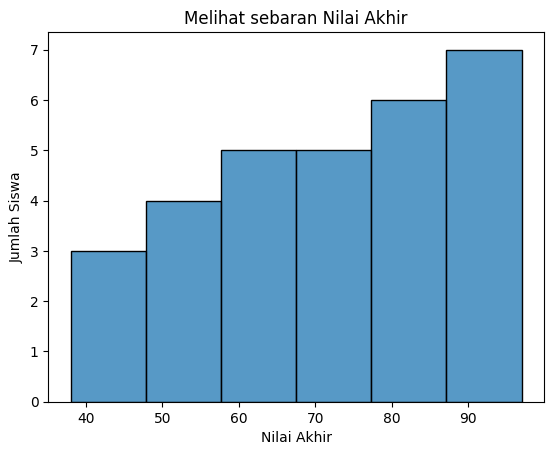

In [61]:
# Histogram Nilai Akhir
sns.histplot(df["nilai_akhir"])
plt.title("Melihat sebaran Nilai Akhir")
plt.xlabel("Nilai Akhir")
plt.ylabel("Jumlah Siswa")
plt.savefig("../images/Sebaran Nilai Akhir.png")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

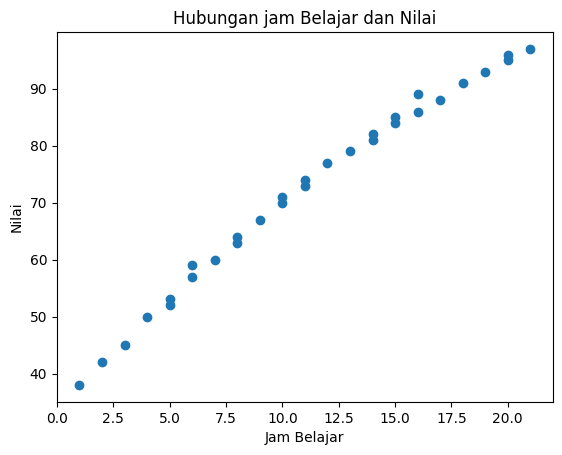

In [60]:
# Scatter jam Belajar vs Nilai
plt.scatter(df["jam_belajar"], df["nilai_akhir"])
plt.title("Hubungan jam Belajar dan Nilai")
plt.xlabel("Jam Belajar")
plt.ylabel("Nilai")
plt.savefig("../images/Jam Belajar vs Nilai.png")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

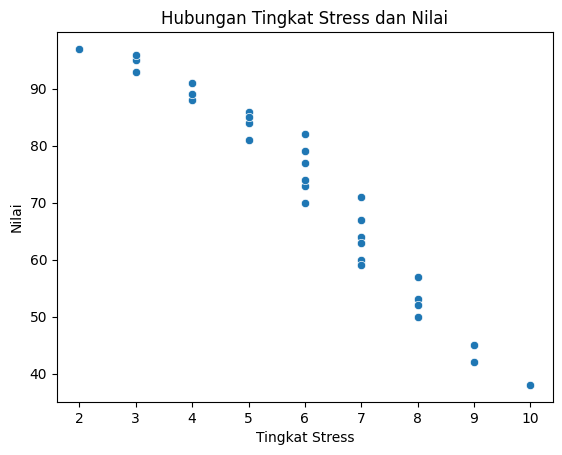

In [59]:
# Scatter Stress vs Nilai
sns.scatterplot(x=df["tingkat_stres"], y=df["nilai_akhir"])
plt.title("Hubungan Tingkat Stress dan Nilai")
plt.xlabel("Tingkat Stress")
plt.ylabel("Nilai")
plt.savefig("../images/Tingkat Stress vs Nilai.png")
plt.show

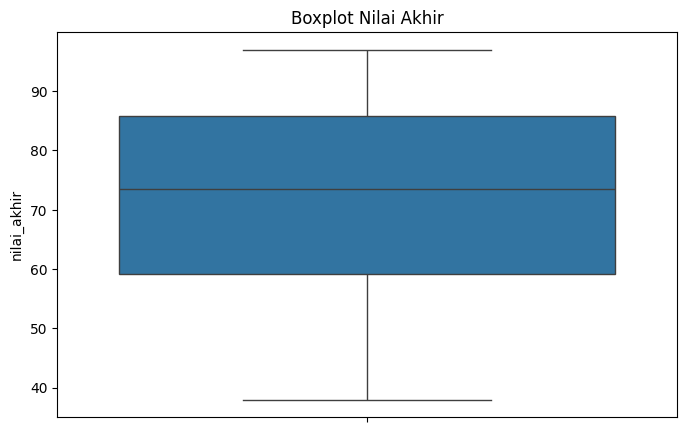

In [58]:
# Boxplot Nilai

plt.figure(figsize=(8,5))
sns.boxplot(y=df["nilai_akhir"])
plt.title("Boxplot Nilai Akhir")
plt.savefig("../images/Boxplot Nilai Akhir.png")
plt.show()


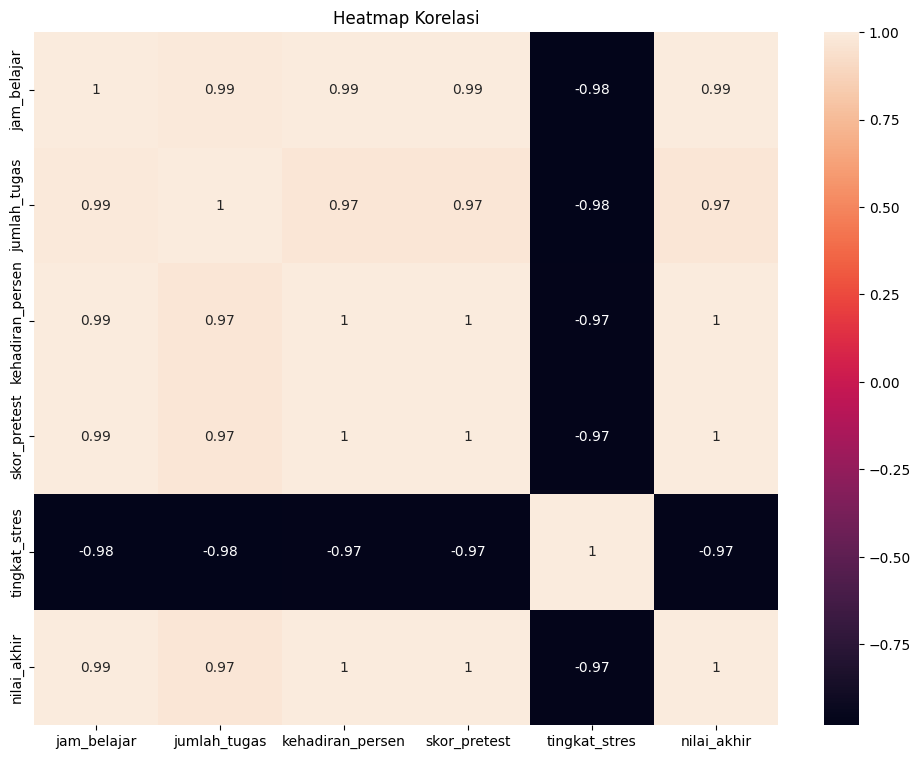

In [64]:
# Heatmap

plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Heatmap Korelasi")
plt.savefig("../images/Heatmap_korelasi.png")
plt.show()

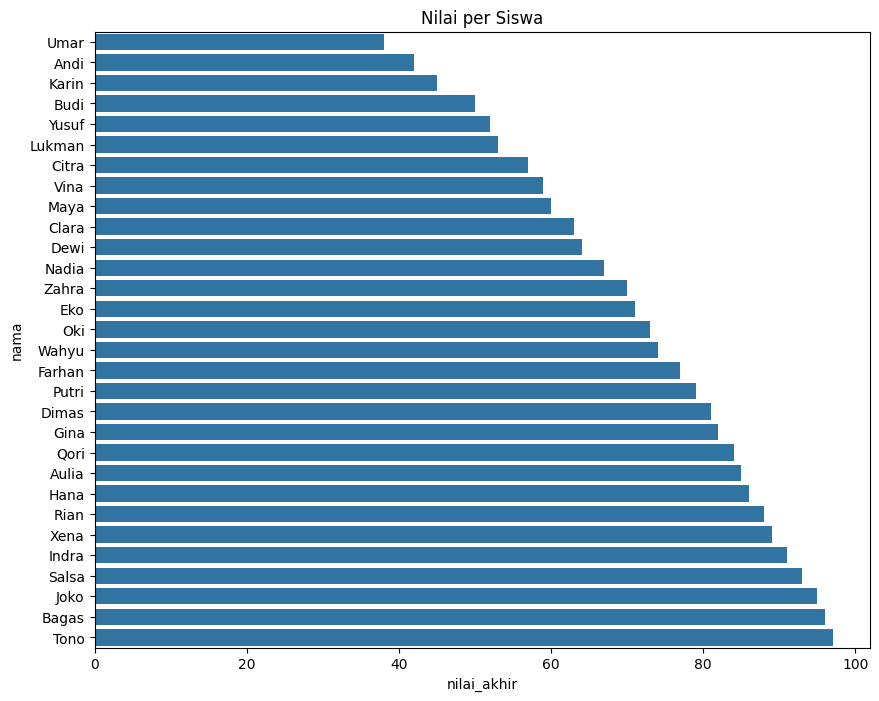

In [55]:
# Barplot Rata-rata Nilai per Siswa

plt.figure(figsize=(10,8))
df_sorted = df.sort_values("nilai_akhir")
sns.barplot(y=df_sorted["nama"], x=df_sorted["nilai_akhir"])

plt.title("Nilai per Siswa")
plt.savefig("../images/Nilai_per_siswa.png")
plt.show()

Feature Selection


In [18]:
# Tentukan fitur model

x = df.drop(columns=["nama", "nilai_akhir"]) # Agar membuang kolom nama dan nilai akhir (untuk yang banyak kolom agar tidak nulis satu satu)
y = df["nilai_akhir"]

In [19]:
# Train Test Split
# Bagi data train dan test

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42
)

In [20]:
# Scaling
# Standarisasi fitur agar skala data seimbang

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


Modeling

In [24]:
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# Prediksi Test Set

y_pred = model.predict(x_test)

Evaluasi

In [26]:
# Hitung performa model

R2  = model.score(x_test, y_test)
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)

print("R2: ", R2)
print("MAE: ", MAE)
print("MSE: ", MSE)

R2:  0.9906877062597417
MAE:  0.45848319206236
MSE:  0.29075050455695534


In [27]:
# Cross Validation

cv_score = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation: ", cv_score)
print("Rata-rata Cross Validation: ", cv_score.mean())

Cross Validation:  [0.99664524 0.99686242 0.99628296 0.99879881 0.99506307]
Rata-rata Cross Validation:  0.9967305019139981


In [28]:
# Feature Importance
# Lihat pengaruh tiap fitur

coef = dict(zip(x.columns, model.coef_))
intercept = model.intercept_

print("coef: ", coef)
print("intercept: ", intercept)

coef:  {'jam_belajar': np.float64(-0.3755712377253424), 'jumlah_tugas': np.float64(1.2042795725843778), 'kehadiran_persen': np.float64(4.705545687772537), 'skor_pretest': np.float64(11.591538575891025), 'tingkat_stres': np.float64(1.2437942706362022)}
intercept:  67.625


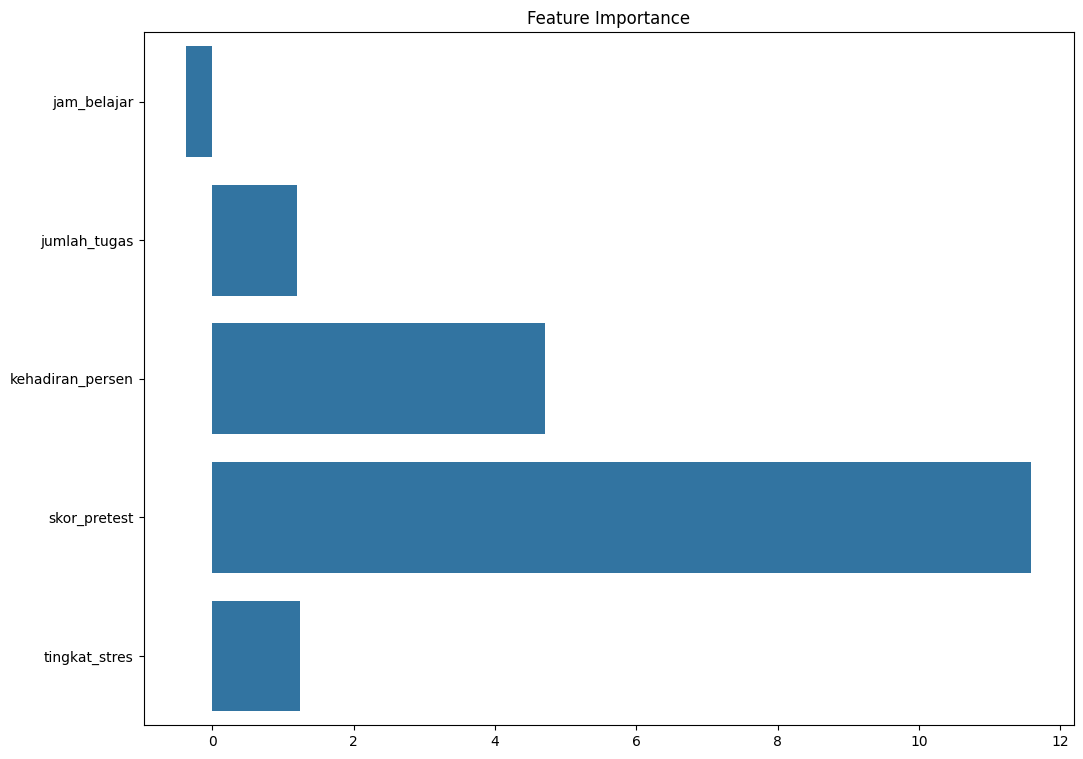

In [65]:
# Melihat faktor yang paling berpengaruh

plt.figure(figsize=(12,9))
sns.barplot(x=list(coef.values()), y=list(coef.keys()))
plt.title("Feature Importance")
plt.savefig("../images/Feature Importance.png")
plt.show()

Prediksi Data Baru

Contoh siswa baru:

jam_belajar = 12

jumlah_tugas = 5

kehadiran = 90

pretest = 80

stres = 4


In [30]:


data_baru_jadi = pd.DataFrame({
    "jam_belajar": [12],
    "jumlah_tugas": [5],
    "kehadiran_persen": [90],
    "skor_pretest": [80],
    "tingkat_stres": [4]
})

data_baru_scaled = scaler.transform(data_baru_jadi)

prediksi = model.predict(data_baru_scaled)

print(prediksi[0])

85.9656129865073


In [42]:
# User Input data baru

jam_belajar = int(input("Masukkan jam belajar: "))
jumlah_tugas = int(input("Masukkan jumlah tugas: "))
kehadiran = int(input("Masukkan kehadiran (%): "))
pretest = int(input("Masukkan skor pretest: "))
stres = int(input("Masukkan tingkat stres (1-10): "))

print("Jam Belajar: ", jam_belajar)
print("Jumlah Tugas: ",jumlah_tugas)
print("Kehadiran: ",kehadiran)
print("Pretest: ",pretest)
print("Stress: ",stres)

Jam Belajar:  1
Jumlah Tugas:  1
Kehadiran:  20
Pretest:  90
Stress:  1


In [43]:
# Hasil prediksi nilai data baru

data_baru = pd.DataFrame([[
    jam_belajar,
    jumlah_tugas,
    kehadiran,
    pretest,
    stres
]], columns=[
    "jam_belajar",
    "jumlah_tugas",
    "kehadiran_persen",
    "skor_pretest",
    "tingkat_stres"
])

hasil = scaler.transform(data_baru)

prediksi = model.predict(hasil)

print(prediksi[0])

62.3465090053499


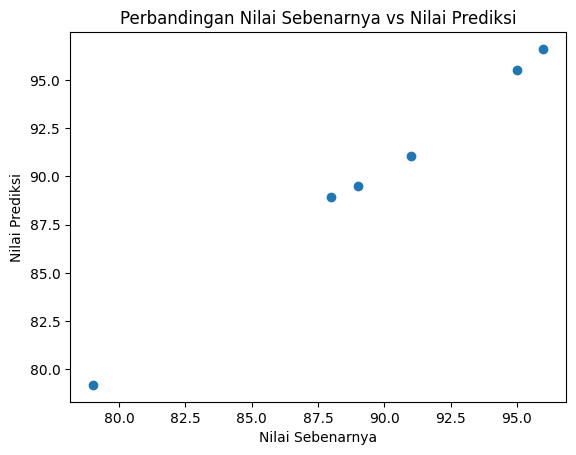

In [53]:
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Sebenarnya")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Sebenarnya vs Nilai Prediksi")
plt.savefig("../images/scatter_actual_vs_pred.png")
plt.show()


KESIMPULAN

Model berhasil memprediksi nilai akhir siswa dengan akurasi R² = 99%.
Faktor paling berpengaruh adalah skor_pretest dan kehadiran.